# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
import cv2
import numpy as np
from PIL import Image

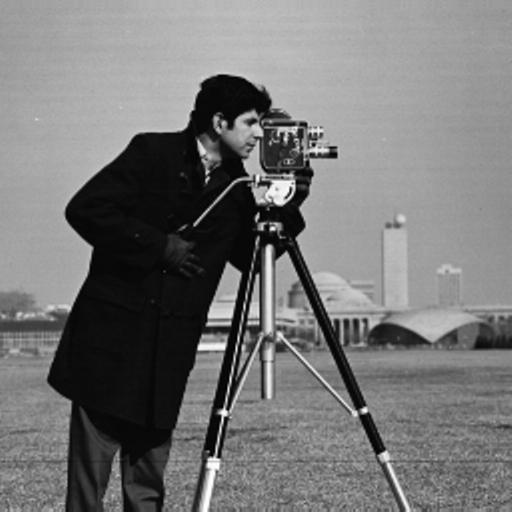

In [4]:
# ── Load image ────────────────────────────────────
img = cv2.imread('cameraman.jpg', 0)

img = Image.fromarray(img)
width, height = img.size
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [5]:
# Get the size of the image
img = Image.open('cameraman.jpg')
width, height = img.size
# scaling factors
scale_factor = 2

In [6]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

new_size = (width * scale_factor, height * scale_factor)
scaled_img = img.resize(new_size)

Original size: 512x512
New size: (1024, 1024)


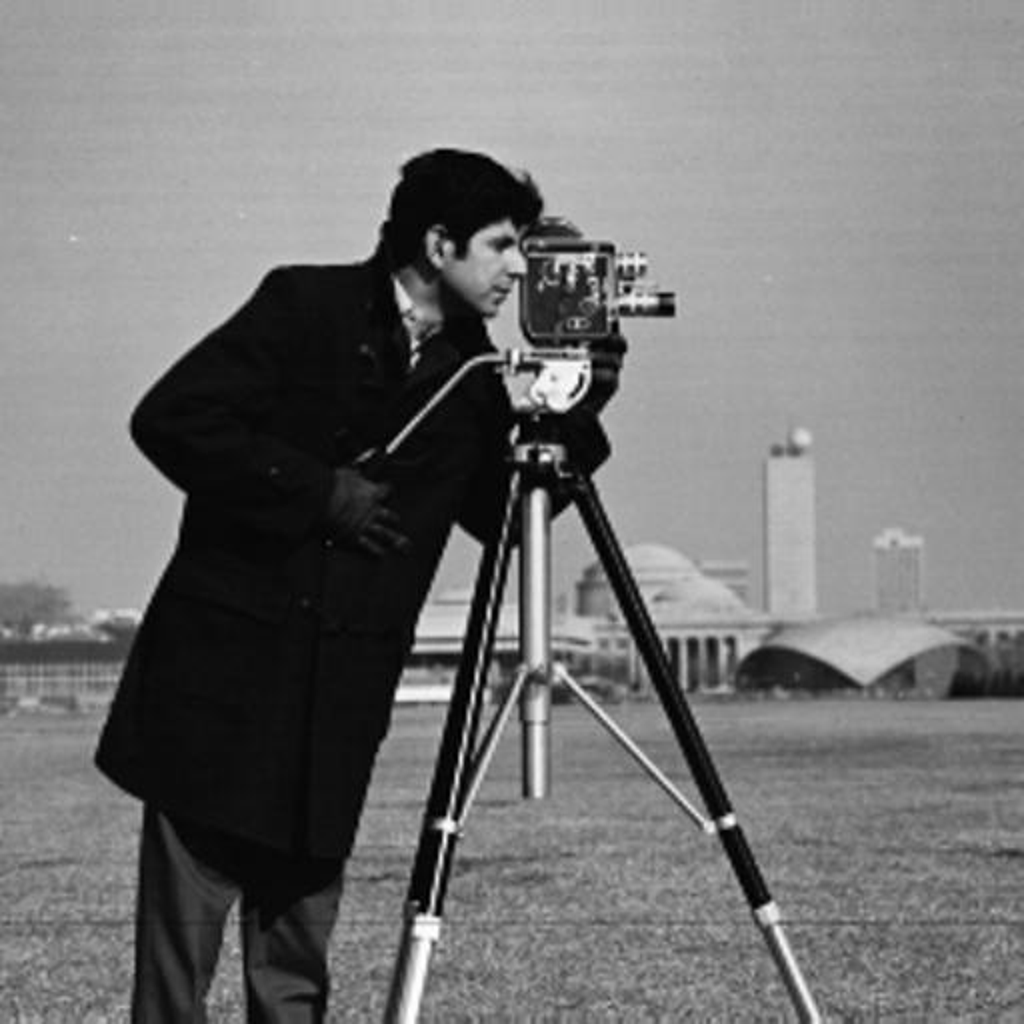

In [7]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save('task1_1_scaled.jpg')
# Print dimensions for the scaling
print(f"Original size: {width}x{height}")
print(f"New size: {scaled_img.size}")
display(scaled_img)

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

Stretched image size: (1024, 512)


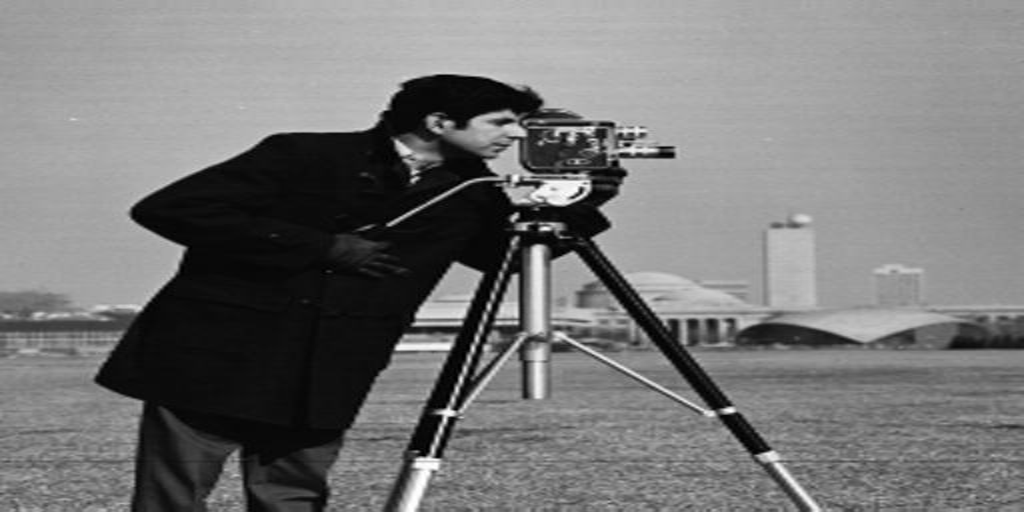

In [8]:
cx = 2
cy = 1
# Calculate the new dimensions
new_width = int(width * cx)
new_height = int(height * cy)

stretched_img = img.resize((new_width, new_height))
stretched_img.save('task1_stretched.jpg')
print(f"Stretched image size: {stretched_img.size}")
display(stretched_img)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated image size: (700, 700)


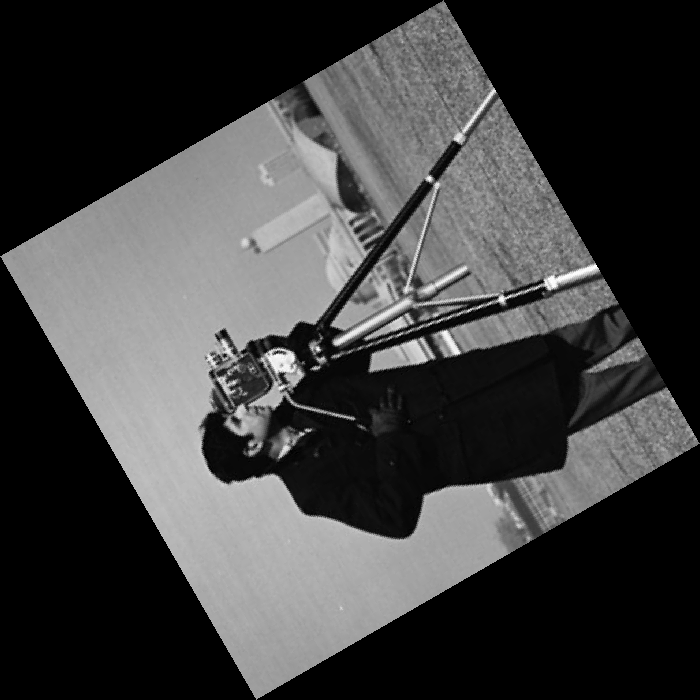

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = img.rotate(120, expand=True)
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save('task1_2_rotated.jpg')

#size of images 
print(f"Original size: {img.size}")
print(f"Rotated image size: {rotated_img.size}")
display(rotated_img)

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5
M_shear = np.float32([[1, shear_factor, 0], [0, 1, 0]])

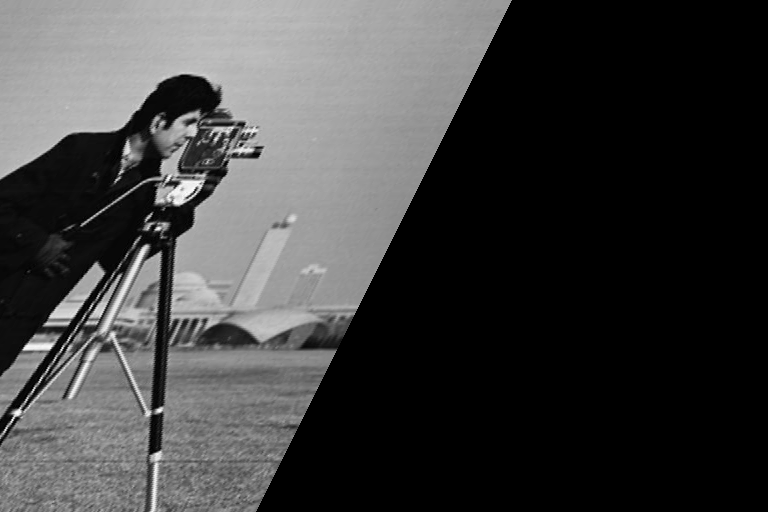

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

shx = 0.5
shear_matrix = (1, shx, 0, 0, 1, 0)
new_width = int(width + abs(shx * height))

sheared_img = img.transform((new_width, height), Image.AFFINE, shear_matrix)


sheared_img.save('task1_3_sheared.jpg')
display(sheared_img)


In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save('task1_3_sheared.jpg')
print("Sheared image saved as task1_3_sheared.jpg")


Sheared image saved as task1_3_sheared.jpg


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

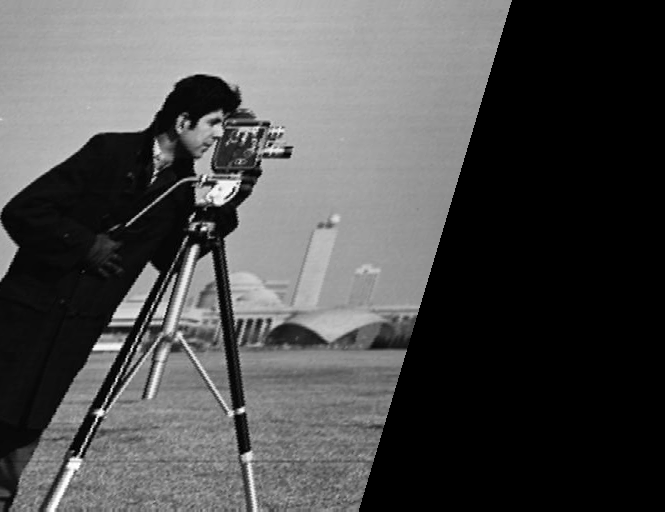

In [14]:
# --- Experiment and compare ---

shx = 0.3 
shy = 0.0 

new_width = int(width + abs(shx * height))
new_height = int(height + abs(shy * width))
shear_matrix = (1, shx, 0, shy, 1, 0)

experiment_img = img.transform((new_width, new_height), Image.AFFINE, shear_matrix)

experiment_img.save('task1_experiment.jpg')
display(experiment_img)#

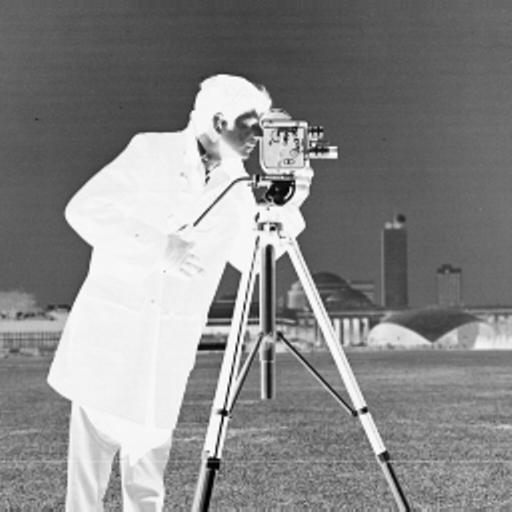

In [15]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

img_array = np.array(img)
negative_array = 255 - img_array
negative_img = Image.fromarray(negative_array)

# Save the negative image (The new image name should be "task2_1_negative.jpg")
negative_img.save('task2_1_negative.jpg')
display(negative_img)


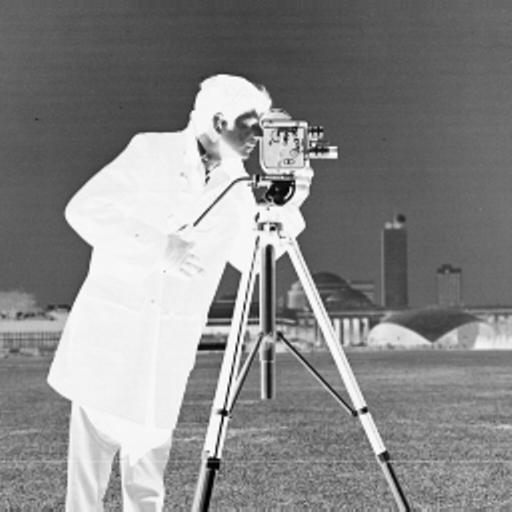

In [16]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

negative_ops_img = ImageOps.invert(img.convert('L'))
negative_ops_img.save('task2_1_negative_ops.jpg')
display(negative_ops_img)

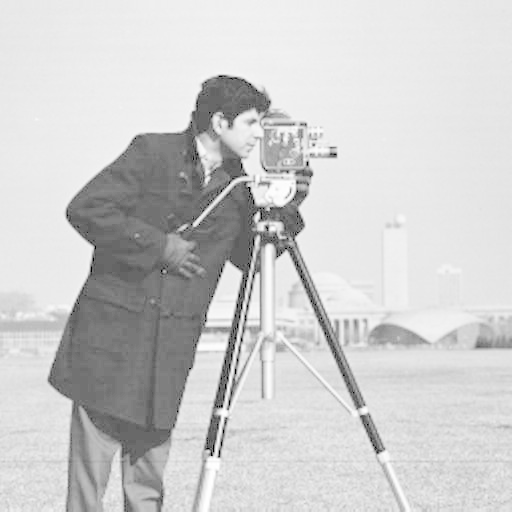

In [17]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)


# Apply the log transformation to each pixel
img_array = np.array(img)
log_transformed = c * (np.log(1 + img_array.astype(float)))
log_transformed = np.array(log_transformed, dtype=np.uint8)

# Create the image from array
log_img = Image.fromarray(log_transformed)

# Save and Show
log_img.save('task2_2_log.jpg')
display(log_img)

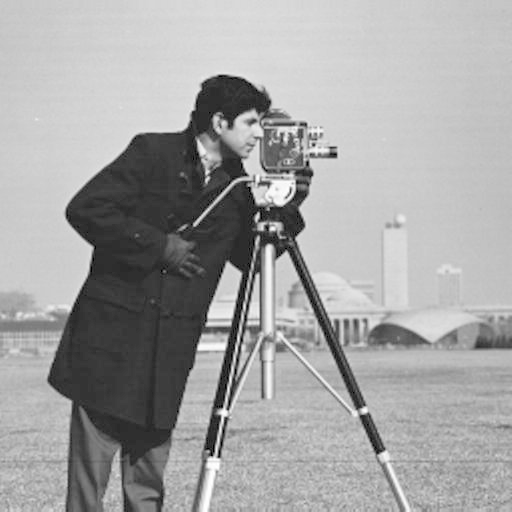

In [18]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5
c = 255 / (np.max(img_array) ** gamma)

# Apply Gamma correction
gamma_transformed = c * (img_array ** gamma)
gamma_transformed = np.array(gamma_transformed, dtype=np.uint8)
gamma_img = Image.fromarray(gamma_transformed)


# Save the gamma image (The new image name should be "task2_3_gamma.jpg")
gamma_img.save('task2_3_gamma.jpg')
display(gamma_img)